In [10]:
import torch
import torchvision
import torchvision.transforms as transforms

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [40]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [41]:
training_data = torchvision.datasets.CIFAR10(
    train=True,
    transform=transform,
    root='./data',
    download=True
)

In [42]:
testing_data = torchvision.datasets.CIFAR10(
    train=False,
    transform=transform,
    root='./data',
    download=True
)

In [43]:
train_loader = torch.utils.data.DataLoader(training_data, batch_size=16,shuffle=True)
test_loader = torch.utils.data.DataLoader(testing_data, batch_size=16,shuffle=True)

In [44]:
image, label = training_data[0]

In [25]:
import sys
!{sys.executable} -m pip install matplotlib

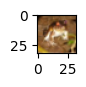

In [90]:
import matplotlib.pyplot as plt
plt.figure(figsize=(0.5,0.5))

plt.imshow(image.permute(1,2,0))

In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):

    def __init__(self, input_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16,out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32,out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.mlp1 = nn.Linear(4*4*64,256)
        self.mlp2 = nn.Linear(256,10)

    def forward(self, x):
        # (3,32,32)
        x = self.conv1(x)
        # (16,32,32)
        x = F.relu(x)
        # (16,32,32)
        x = self.pool(x)
        # (16,16,16)
        x = self.conv2(x)
        # (32,16,16)
        x = F.relu(x)
        # (32,16,16)
        x = self.pool(x)
        # (32,8,8)
        x = self.conv3(x)
        # (32,8,8)
        x = F.relu(x)
        # (64,8,8)
        x = self.pool(x)
        # (64,4,4)
        x = x.view(x.size(0), -1)
        # flatten
        x = self.mlp1(x)
        x = self.mlp2(x)
        return x

In [78]:
model = CNN(3)
lossfn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for _ in range(100):
    for batch in train_loader:
        train_set, train_label = batch
        optimizer.zero_grad()
        output = model(train_set)
        loss = lossfn(output, train_label)
        loss.backward()
        optimizer.step()
    print(loss.item())

0.5626429319381714
0.5230240821838379
0.8254976868629456
1.6799966096878052
0.9896277785301208
0.4872373938560486
1.018069863319397
0.7066007256507874
0.9132963418960571
0.9047296643257141
0.6473835706710815
0.9343031644821167
0.29482653737068176
0.6684796810150146
1.0963445901870728
0.8823652267456055
0.6097278594970703
0.8583269715309143
0.32583898305892944
0.4679962992668152
0.9374620914459229
0.6121840476989746
0.4925088584423065
0.35602903366088867
0.3070201575756073
0.728908360004425
0.5866765379905701
0.26687633991241455
0.43284285068511963
0.2965221405029297
0.3144509494304657
0.8088661432266235
0.39547431468963623
0.18758469820022583
0.5013008117675781
0.32636910676956177
0.39910823106765747
0.2742791771888733
0.28453370928764343
0.43149012327194214
0.628803014755249
0.5312302708625793
0.31011664867401123
0.2075101137161255
0.3375980854034424
0.4675899147987366
0.6056904196739197
0.4693280756473541
0.13023796677589417
0.6795176267623901
0.09401620179414749
0.4734916388988495
0

In [83]:
total = 0
correct = 0
with torch.no_grad():
    for batch in test_loader:
        test_set, test_labels = batch
        predicted_label = model(test_set)
        predictions = torch.max(predicted_label, 1)
        correct += (predictions.indices == test_labels).sum().item()
        total += test_labels.shape[0]

In [86]:
correct/total

0.6859